### EDA of Retail Sales Data

**Project Overview**

This project explores a retail transaction dataset sourced from Kaggle, containing customer, product, pricing, payment, and order status information. The dataset was deliberately designed with real-world data quality issues — missing values, inconsistent column naming, formatting problems, outliers, and data entry errors — making it well suited for practicing data cleaning and exploratory data analysis.

The goals of this project are to: clean and validate the raw data, explore patterns and relationships within it, and use those findings to inform a classification model that could support a business decision (e.g. predicting order outcomes or payment behavior).

**Notebook Structure**

1. **Data Loading & Initial Exploration** — Load the dataset and inspect its shape, column names, dtypes, and basic statistics.
2. **Data Cleaning & Preprocessing** — Identify and resolve missing values, inconsistent formatting, outliers, and data entry errors.
3. **Exploratory Data Analysis (EDA)** — Examine individual variable distributions, then relationships between variables relevant to the eventual modeling target.
4. **Key Findings** — Summary of the most important patterns and data quality issues uncovered.
5. **Modeling** — A classification model built on the cleaned data, informed by the EDA findings.



In [71]:
# Importing necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [72]:
#loading the dataset

raw_data = pd.read_csv('messy_ecommerce_sales_data.csv')
raw_data

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
0,100,Customer_100,ORD-41285,11/22/2024,Blender,Home,3,38,Cash on Delivery,Shipped,114.000
1,101,Customer_101,ORD-35783,7/5/2025,Smartphone,Electronics,2,abd,PayPal,Processing,NaN
2,102,Customer_102,ORD-84355,12/23/2024,Tennis Racket,Sports,1,389.05,PayPal,Delivered,389.050
3,103,Customer_103,ORD-57811,3/19/2025,Science,Books,5,233.92,PayPal,Processing,1169.600
4,104,Customer_104,ORD-93614,10/20/2025,Biography,Books,1,552.51,Cash on Delivery,Processing,552.510
...,...,...,...,...,...,...,...,...,...,...,...
98,198,Customer_198,ORD-14608,7/27/2025,Vacuum,NaN,2,497.01,Cash on Delivery,Shipped,994.020
99,199,Customer_199,ORD-82922,1/22/2025,Blender,Home,5,372.28,Credit Card,Shipped,1861.400
100,175,Customer_175,ORD-56651,2/24/2025,Headphones,Electronics,1,111.36,Credit Card,Processing,77.952
101,142,Customer_142,ORD-69018,10/30/2025,Shoes,Clothing,5,645.26,Credit Card,Shipped,3226.300


### First Glance Observations

- Customer names contain underscores between words. These should be removed for a standard, readable format.
- The Date column uses `/` as a separator instead of `-`; this may need to be corrected and converted to a proper datetime dtype.
- The Category column contains null values that may need to be addressed.
- The Price column contains strings mixed in with numeric values — these may need to be identified and handled before the dtype can be converted.
- The Total column has too many decimal places and may need to be rounded to two.
- There are some Null values that will need to be dealt with

In [73]:
#checking shape

raw_data.shape

(103, 11)

In [74]:
# checking nulls and data types

raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              103 non-null    int64  
 1    Customer_Name  103 non-null    str    
 2   Order_ID        103 non-null    str    
 3   Order_Date      103 non-null    str    
 4   Product         103 non-null    str    
 5    Category       95 non-null     str    
 6   Quantity        98 non-null     str    
 7   Price           98 non-null     str    
 8   Payment_Method  103 non-null    str    
 9   Status          103 non-null    str    
 10  Total           89 non-null     float64
dtypes: float64(1), int64(1), str(9)
memory usage: 9.0 KB


### Missing Values & Dtype Corrections

- There are 4 columns with missing values: Category, Quantity, Price, and Total.
- Total has a slightly higher number of nulls, but these may be calculable from the other available information in each row (e.g. Price × Quantity).
- Order Date needs to be converted to a datetime dtype.
- Quantity needs to be converted to an integer dtype.
- Price needs to be converted to a float dtype.
- All string columns (names and values) will undergo standard cleaning — removing extra spaces and applying consistent capitalization where needed.

In [75]:
#checking percentage of nulls

null_percentages = ((raw_data.isnull().sum() / len(raw_data)) * 100).sort_values(ascending=False)
null_percentages

Total             13.592233
 Category          7.766990
Price              4.854369
Quantity           4.854369
Order_ID           0.000000
ID                 0.000000
 Customer_Name     0.000000
Order_Date         0.000000
Product            0.000000
Payment_Method     0.000000
Status             0.000000
dtype: float64

### Missing Values Strategy

For each column, I will calculate the percentage of missing values and handle them as follows:

- **< 5% missing** — Drop rows. Too small a portion to meaningfully impact the model.
- **5% – 40% missing** — Impute (mean/median/mode). Too valuable to discard, and enough data exists to estimate reliably.
- **> 40% missing** — Drop the column. More noise than signal, unless `AdditionalInfo` can be used to recover values.

In [76]:
#dropping the nulls in the price and quantity columns

raw_data = raw_data.dropna(subset=['Price', 'Quantity'])
null_percentages2 = ((raw_data.isnull().sum() / len(raw_data)) * 100).sort_values(ascending=False)
null_percentages2



 Category         7.526882
Total             4.301075
ID                0.000000
Order_ID          0.000000
 Customer_Name    0.000000
Product           0.000000
Order_Date        0.000000
Quantity          0.000000
Price             0.000000
Payment_Method    0.000000
Status            0.000000
dtype: float64

### Price Column Data Entry Errors

- Row 1 — Price contains random, non-numeric characters and Total is also missing, leaving no usable value to work with; this row will be dropped.
- Row 2 — Price is written out in words (e.g. "four hundred"); this will be converted to numeric and the calculation completed.
- Row 3 — Price includes a dollar sign after the number (e.g. "200$"); the symbol will be stripped and the calculation completed.
- Row 4 — Price contains a typo-like entry ("4a"); this is assumed to be a data entry error and will be corrected before completing the calculation.

In [77]:
# removing the first row
raw_data = raw_data.drop(raw_data.index[1])



# replace the four hundred in the 10th row
raw_data['Price'] = raw_data['Price'].replace('four hundred', '400')

# remove the dollar sign from the price column and convert it to float
raw_data['Price'] = raw_data['Price'].str.replace('$', '')

# remove the 'a' from the quantity column
raw_data['Quantity'] = raw_data['Quantity'].str.replace('a', '')




In [78]:
null_rows = raw_data[raw_data[['Price', 'Quantity', 'Total']].isnull().any(axis=1)][['Price', 'Quantity', 'Total']]
null_rows

,Price,Quantity,Total
10,400,5,NaN
20,300,5,NaN
92,203.63,4,NaN


In [79]:
raw_data.loc[null_rows.index] 

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
10,110,Customer_110,ORD-61020,9/26/2025,Basketball,sports,5,400,Cash on Delivery,Cancelled,NaN
20,120,Customer_120,ORD-14659,6/13/2025,Yoga Mat,ELECTRONICS,5,300,Credit Card,Cancelled,NaN
92,192,Customer_192,ORD-35144,abc,Jacket,Clothing,4,203.63,Credit Card,Returned,NaN


In [80]:
#changing column data types

raw_data['Price'] = raw_data['Price'].astype(float)
raw_data['Quantity'] = raw_data['Quantity'].astype(int)

In [81]:
#calculating missing values in the Total column and filling them with Price * Quantity

raw_data['Total'] = raw_data['Price'] * raw_data['Quantity']

raw_data.isnull().sum()

ID                0
 Customer_Name    0
Order_ID          0
Order_Date        0
Product           0
 Category         7
Quantity          0
Price             0
Payment_Method    0
Status            0
Total             0
dtype: int64

In [82]:
raw_data[raw_data[' Category'].isnull()]

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
33,133,Customer_133,ORD-68182,12/5/2024,Biography,NaN,5,343.24,Credit Card,Shipped,1716.20
36,136,Customer_136,ORD-20985,6/12/2025,Headphones,NaN,1,696.71,Credit Card,Delivered,696.71
80,180,Customer_180,ORD-86629,3/26/2025,Laptop,NaN,2,418.38,Credit Card,Processing,836.76
81,181,Customer_181,ORD-54481,12/29/2024,Smartphone,NaN,1,266.48,Cash on Delivery,Cancelled,266.48
82,182,Customer_182,ORD-79672,8/3/2025,Shoes,NaN,4,538.35,PayPal,Processing,2153.40
84,184,Customer_184,ORD-67799,2/15/2025,Jeans,NaN,4,101.19,Bank Transfer,Processing,404.76
98,198,Customer_198,ORD-14608,7/27/2025,Vacuum,NaN,2,497.01,Cash on Delivery,Shipped,994.02


In [83]:
print(raw_data[' Category'].unique())

<StringArray>
[       'Home',      'Sports',       'Books',      'sports',    'Clothing',
 'Electronics',  'electronic', 'ELECTRONICS', 'electronics',           nan]
Length: 10, dtype: str


In [84]:
#Taking care of 4 different types pf electronics

raw_data.loc[raw_data[' Category'].str.contains('elec', case=False, na=False), ' Category'] = 'Electronics'

In [85]:
#placing items with null category into the correct category

raw_data.loc[33,' Category'] = 'Books'
raw_data.loc[[36, 80, 81], ' Category'] = 'Electronics'
raw_data.loc[[82,84], ' Category'] = 'Clothing'
raw_data.loc[[98], ' Category'] = 'Home'

raw_data.isnull().sum()








ID                0
 Customer_Name    0
Order_ID          0
Order_Date        0
Product           0
 Category         0
Quantity          0
Price             0
Payment_Method    0
Status            0
Total             0
dtype: int64

In [86]:
raw_data.columns = raw_data.columns.str.replace('_', ' ')
raw_data.columns = raw_data.columns.str.strip().str.title()

raw_data.columns


Index(['Id', 'Customer Name', 'Order Id', 'Order Date', 'Product', 'Category',
       'Quantity', 'Price', 'Payment Method', 'Status', 'Total'],
      dtype='str')

In [87]:
raw_data.info()

<class 'pandas.DataFrame'>
Index: 92 entries, 0 to 102
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Id              92 non-null     int64  
 1   Customer Name   92 non-null     str    
 2   Order Id        92 non-null     str    
 3   Order Date      92 non-null     str    
 4   Product         92 non-null     str    
 5   Category        92 non-null     str    
 6   Quantity        92 non-null     int64  
 7   Price           92 non-null     float64
 8   Payment Method  92 non-null     str    
 9   Status          92 non-null     str    
 10  Total           92 non-null     float64
dtypes: float64(2), int64(2), str(7)
memory usage: 10.7 KB


In [88]:
# cleaning up string columns

string_columns = ['Order Id', 'Product', 'Category', 'Customer Name', 'Payment Method', 'Status']

for col in string_columns:
    raw_data[col] = raw_data[col].str.strip().str.title()

In [89]:
cleaned_data = raw_data.copy()

# check for duplicates in the cleaned data

cleaned_data.duplicated().sum()

np.int64(3)

In [90]:
cleaned_data

,Id,Customer Name,Order Id,Order Date,Product,Category,Quantity,Price,Payment Method,Status,Total
0,100,Customer_100,Ord-41285,11/22/2024,Blender,Home,3,38.00,Cash On Delivery,Shipped,114.00
2,102,Customer_102,Ord-84355,12/23/2024,Tennis Racket,Sports,1,389.05,Paypal,Delivered,389.05
3,103,Customer_103,Ord-57811,3/19/2025,Science,Books,5,233.92,Paypal,Processing,1169.60
4,104,Customer_104,Ord-93614,10/20/2025,Biography,Books,1,552.51,Cash On Delivery,Processing,552.51
5,105,Customer_105,Ord-22442,11/20/2024,Tennis Racket,Sports,3,122.06,Cash On Delivery,Cancelled,366.18
...,...,...,...,...,...,...,...,...,...,...,...
98,198,Customer_198,Ord-14608,7/27/2025,Vacuum,Home,2,497.01,Cash On Delivery,Shipped,994.02
99,199,Customer_199,Ord-82922,1/22/2025,Blender,Home,5,372.28,Credit Card,Shipped,1861.40
100,175,Customer_175,Ord-56651,2/24/2025,Headphones,Electronics,1,111.36,Credit Card,Processing,111.36
101,142,Customer_142,Ord-69018,10/30/2025,Shoes,Clothing,5,645.26,Credit Card,Shipped,3226.30


In [91]:
cleaned_data[cleaned_data.duplicated(keep=False)]

,Id,Customer Name,Order Id,Order Date,Product,Category,Quantity,Price,Payment Method,Status,Total
42,142,Customer_142,Ord-69018,10/30/2025,Shoes,Clothing,5,645.26,Credit Card,Shipped,3226.30
46,146,Customer_146,Ord-32755,7/9/2025,Basketball,Electronics,2,705.42,Bank Transfer,Processing,1410.84
75,175,Customer_175,Ord-56651,2/24/2025,Headphones,Electronics,1,111.36,Credit Card,Processing,111.36
100,175,Customer_175,Ord-56651,2/24/2025,Headphones,Electronics,1,111.36,Credit Card,Processing,111.36
101,142,Customer_142,Ord-69018,10/30/2025,Shoes,Clothing,5,645.26,Credit Card,Shipped,3226.30
102,146,Customer_146,Ord-32755,7/9/2025,Basketball,Electronics,2,705.42,Bank Transfer,Processing,1410.84


In [92]:
# dropping the duplicates

cleaned_data = cleaned_data.drop_duplicates(keep='first')
cleaned_data.duplicated().sum()

np.int64(0)

## EDA

In [93]:
cleaned_data.describe()

,Id,Quantity,Price,Total
count,89.000000,89.000000,89.000000,89.000000
mean,149.595506,2.910112,608.730225,1252.704944
std,28.442813,1.800508,1041.142768,2601.668863
min,100.000000,-5.000000,-100.000000,-20000.000000
25%,126.000000,2.000000,266.700000,600.290000
50%,149.000000,3.000000,530.520000,1212.600000
75%,174.000000,4.000000,736.710000,2092.040000
max,199.000000,5.000000,10000.000000,4722.700000


We have a total of 89 entries to work with.

We have 20 different products across 5 categories, 4 payment methods, and 5 status points.

Customer_100 is the top customer, Order_41285 is the top order, 2/9/2025 is the top order date, Blender is the top product, Books is the top category, Cash on Delivery is the top payment method, and Returned is the top status (this is concerning and likely what I'll build a model around; also worth investigating which products or categories are driving returns, in case it's an inventory issue).

Every customer name appears only once (freq = 1) across 89 rows, meaning there are no repeat customers in this dataset. Worth flagging as a data limitation and something to dig into.

The Blender appears 7 times as the top product (ahead, but not by a wide margin). Books appears 22 times, a significant share of orders. Cash on Delivery appears 30 times, also significant. Returned status appears 25 times, which is concerning.
Price, Quantity, and Total all have negative minimums, which are likely data entry errors and should be addressed.

For Total: mean (1252.70) and median (1212.60) are close, suggesting no strong skew by that measure alone. However, std (2601.67) is more than double the mean, signaling a wide spread likely driven by outliers (e.g. the -20000 min and 10000 max in Price) rather than a shift in the bulk of the data. Distribution shape should be confirmed visually (histogram/boxplot) once negatives are cleaned, rather than assumed from .describe() alone.



In [94]:
# getting the different types of products in the dataset

product_types = cleaned_data['Product'].unique()

# category types in the dataset

category_types = cleaned_data['Category'].unique()

print("Product Types:", product_types)
print("Category Types:", category_types)

Product Types: <StringArray>
[      'Blender', 'Tennis Racket',       'Science',     'Biography',
    'Basketball',        'Comics',         'Shoes',       'Fiction',
    'Smartphone',      'Yoga Mat',     'Microwave',        'Vacuum',
          'Lamp',       'T-Shirt',    'Smartwatch',    'Headphones',
      'Football',        'Laptop',        'Jacket',         'Jeans']
Length: 20, dtype: str
Category Types: <StringArray>
['Home', 'Sports', 'Books', 'Clothing', 'Electronics']
Length: 5, dtype: str


In [99]:
numeric_columns = ['Price', 'Quantity', 'Total']    

for col in numeric_columns:
    negative = cleaned_data[cleaned_data[col] < 0]

negative

,Id,Customer Name,Order Id,Order Date,Product,Category,Quantity,Price,Payment Method,Status,Total


In [100]:
cleaned_data.loc[37, 'Price'] = 100
cleaned_data.loc[37, 'Total'] = 300


In [101]:

#dealing with outliers



for col in numeric_columns:
    Q1 = cleaned_data[col].quantile(0.25)
    Q3 = cleaned_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    cleaned_data = cleaned_data[(cleaned_data[col] >= lower_bound) & (cleaned_data[col] <= upper_bound)]

cleaned_data.describe()




,Id,Quantity,Price,Total
count,84.000000,84.000000,84.000000,84.000000
mean,149.714286,2.988095,489.231786,1447.600476
std,28.597991,1.492907,257.363083,1042.014645
min,100.000000,1.000000,38.000000,40.950000
25%,125.750000,2.000000,261.815000,645.807500
50%,150.500000,3.000000,500.530000,1191.100000
75%,174.250000,4.000000,698.887500,2016.510000
max,199.000000,5.000000,942.760000,4133.850000


- Means for all numeric columns are now greater than std, there are less likely to be outliers the medians and mean are also now relativly close so the distribution has been normalised

Means for all numeric columns are now greater than std, indicating outliers are less likely. Medians and means are also closer than before, suggesting the distributions are more normalized after cleaning. Total still shows a mild right skew (mean and median remain somewhat apart, and the max is roughly double the 75th percentile), so this should be confirmed visually. Univariate analysis follows to examine each column's distribution in more detail.

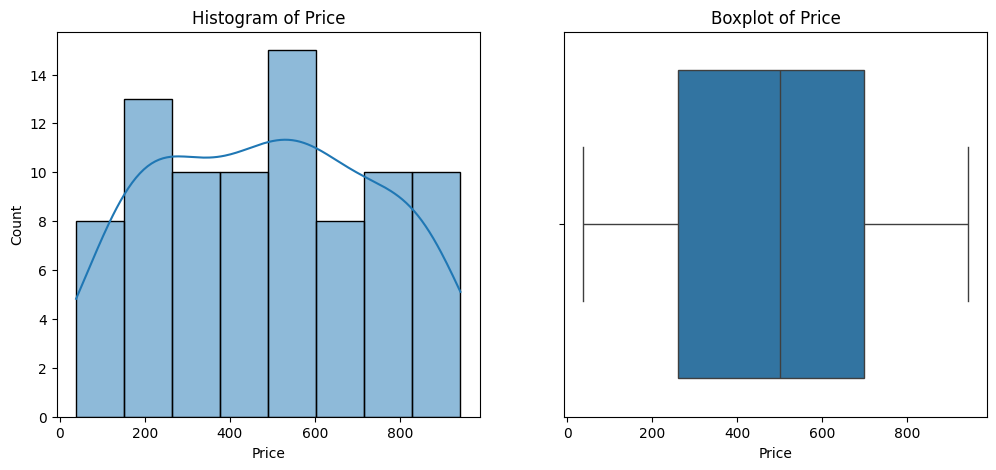

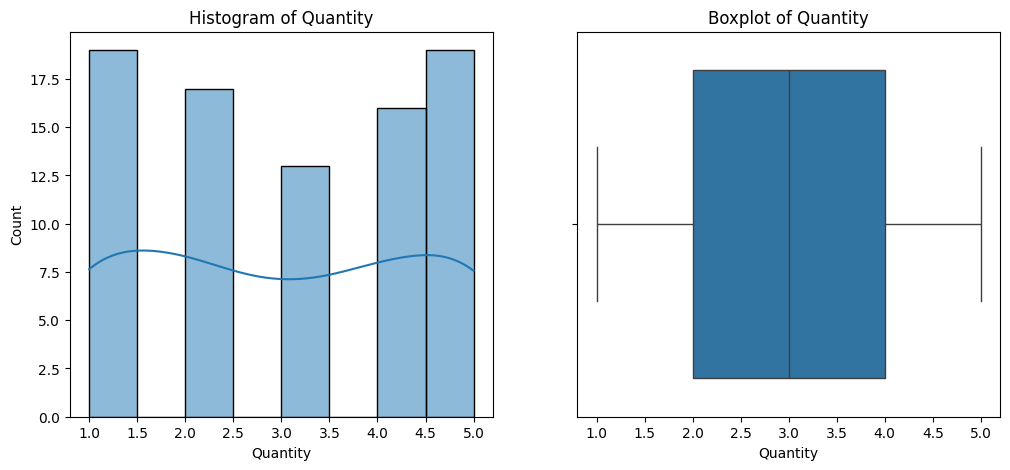

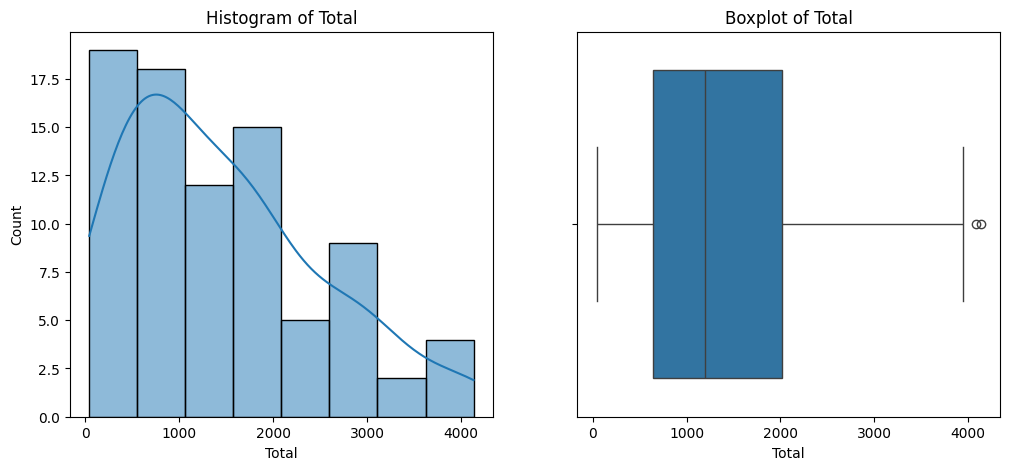

In [102]:
# histograms and box plots for numeric columns 

for col in numeric_columns:
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    sns.histplot(cleaned_data[col], kde=True)
    plt.title(f'Histogram of {col}')
    
    plt.subplot(1, 2, 2)
    sns.boxplot(x=cleaned_data[col])
    plt.title(f'Boxplot of {col}')
    
    plt.show()

Quantity: There are no flaggable outliers. Relatively uniform distribution, roughly symmetric..

Total: right skewed, most totals less than 2000, outliers present beyond the right whisker around 3900-4000

Prices: Uniform distribution, roughly symmetric, no outliers flagged.





